In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler


import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams
from matplotlib.cm import rainbow
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv("../input/data.csv")

In [3]:
df.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.info() # feature attributes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.isnull().sum() # verifying absence of null values

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
df.duplicated().sum() # verifying for duplicate rows

0

In [8]:
df.describe().T # statistical info

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


ValueError: num must be 1 <= num <= 9, not 10

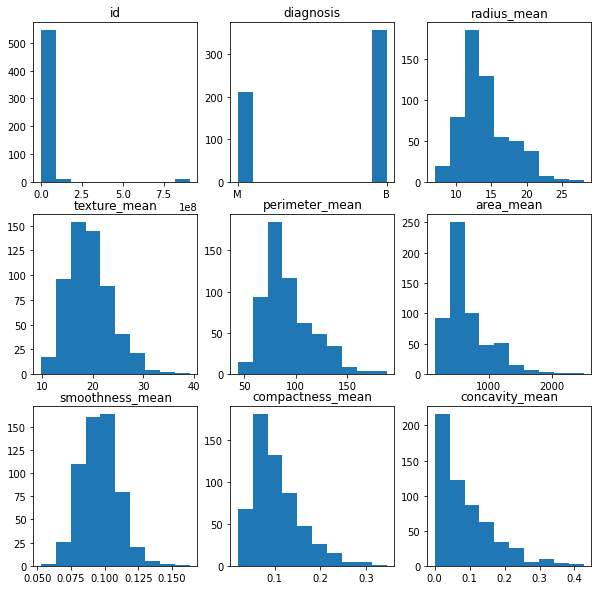

In [9]:
numlist=df.columns
fig = plt.figure(figsize=(10,10))
for i in range(len(numlist)):
    plt.subplot(3,3,i+1)
    plt.title(numlist[i],fontsize=12)
    plt.hist(df[numlist[i]])

plt.tight_layout()

In [ ]:
### BEGIN SOLUTION
float_columns = [x for x in df.columns]

# The correlation matrix
corr_mat = df[float_columns].corr()

# Strip out the diagonal values for the next step

#for x in range(len(float_columns)):
  #corr_mat.loc[x,x] = 0.0
    
corr_mat

In [ ]:
plt.figure(figsize = (30,30))
sns.heatmap(corr_mat,annot=True, cbar=False, cmap='Blues', fmt='.1f')

In [ ]:
X=df[df.columns[2:32]]
y=df[df.columns[1]]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0, stratify=y)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

#K Nearest Neighbor

In [ ]:
knr = KNeighborsClassifier(n_neighbors=6).fit(X_train, y_train)
print("train score - " + str(knr.score(X_train, y_train)))
print("test score - " + str(knr.score(X_test, y_test)))

#Logistic Regression

In [ ]:
lr1 = LogisticRegression(random_state=0).fit(X_train, y_train)
print("train score - " + str(lr1.score(X_train, y_train)))
print("test score - " + str(lr1.score(X_test, y_test)))

###After Tuning
####Increased Regularization Parameter (C) value

In [ ]:
lr2 = LogisticRegression(C=6, random_state=0).fit(X_train, y_train)
print("train score - " + str(lr2.score(X_train, y_train)))
print("test score - " + str(lr2.score(X_test, y_test)))

#Linear SVC

In [ ]:
svc = LinearSVC(random_state=0).fit(X_train,y_train)
print("train score - " + str(svc.score(X_train, y_train)))
print("test score - " + str(svc.score(X_test, y_test)))

###After Tuning
####Increased Regularization Parameter (C) value

In [ ]:
svc = LinearSVC(C=3, random_state=0).fit(X_train,y_train)
print("train score - " + str(svc.score(X_train, y_train)))
print("test score - " + str(svc.score(X_test, y_test)))

SVC Models are good when the data is scaled. Lets scale the data and build the model

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svc_scaled = LinearSVC(C=2, random_state=0).fit(X_train_scaled,y_train)
print("train score - " + str(svc_scaled.score(X_train_scaled, y_train)))
print("test score - " + str(svc_scaled.score(X_test_scaled, y_test)))

#Decision Tree

In [ ]:
dec = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
print("train score - " + str(dec.score(X_train, y_train)))
print("test score - " + str(dec.score(X_test, y_test)))

###After Tuning
####Pre-pruning by reducing maximum depth to 5

In [ ]:
dec = DecisionTreeClassifier(max_depth=5, random_state=0).fit(X_train, y_train)
print("train score - " + str(dec.score(X_train, y_train)))
print("test score - " + str(dec.score(X_test, y_test)))

#Random Forest

In [ ]:
forest = RandomForestClassifier(n_estimators=10, random_state=0).fit(X_train, y_train)
print("train score - " + str(forest.score(X_train, y_train)))
print("test score - " + str(forest.score(X_test, y_test)))

###After Tuning
####Increased n_estimators to 100 and max_features to 30. Max depth restricted to 5

In [ ]:
forest = RandomForestClassifier(n_estimators=100, max_features=30, max_depth=5, random_state=0).fit(X_train, y_train)
print("train score - " + str(forest.score(X_train, y_train)))
print("test score - " + str(forest.score(X_test, y_test)))

#Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier().fit(X_train, y_train)
print("train score - " + str(gb.score(X_train, y_train)))
print("test score - " + str(gb.score(X_test, y_test)))

###After Tuning
####Increased learning rate to 0.15 from default 0.1

In [ ]:
gb = GradientBoostingClassifier(random_state=0, learning_rate=0.15).fit(X_train, y_train)
print("train score - " + str(gb.score(X_train, y_train)))
print("test score - " + str(gb.score(X_test, y_test)))

#Conclusion

We can see Support Vector Machine (SVM) model with scaled data is giving a very good score on test data.

In [ ]:
print("Support Vector Machine test score - " + str(svc_scaled.score(X_test_scaled, y_test)))
print("Gradient Boosting test score - " + str(gb.score(X_test, y_test)))
print("Logistic Regression test score - " + str(lr2.score(X_test, y_test)))